In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
import math
import cmath

In [2]:
class QuadraticState(TypedDict):
    a: float
    b: float
    c: float

    discriminant: float
    result: str


In [3]:

def calculate_discriminant(state: QuadraticState):

    a = state["a"]
    b = state["b"]
    c = state["c"]

    d = (b ** 2) - (4 * a * c)

    return {
        "discriminant": d
    }



In [4]:
def route_solver(state: QuadraticState):

    d = state["discriminant"]

    if d > 0:
        return "two_roots"

    elif d == 0:
        return "one_root"

    else:
        return "complex_roots"

In [5]:
def solve_two_roots(state: QuadraticState):

    a = state["a"]
    b = state["b"]
    d = state["discriminant"]

    x1 = (-b + math.sqrt(d)) / (2 * a)
    x2 = (-b - math.sqrt(d)) / (2 * a)

    return {
        "result": f"Two Real Roots: {x1} and {x2}"
    }


def solve_one_root(state: QuadraticState):

    a = state["a"]
    b = state["b"]

    x = (-b) / (2 * a)

    return {
        "result": f"One Repeated Root: {x}"
    }
    
    

def solve_complex_roots(state: QuadraticState):

    a = state["a"]
    b = state["b"]
    d = state["discriminant"]

    x1 = (-b + cmath.sqrt(d)) / (2 * a)
    x2 = (-b - cmath.sqrt(d)) / (2 * a)

    return {
        "result": f"Complex Roots: {x1} and {x2}"
    }


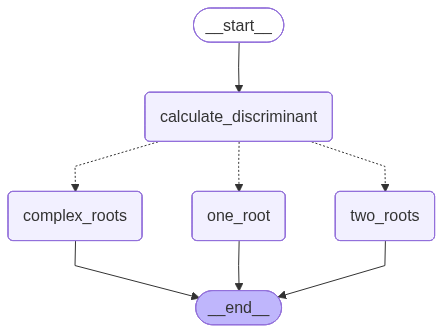

In [10]:
graph = StateGraph(QuadraticState)

graph.add_node(
    "calculate_discriminant",
    calculate_discriminant
)

graph.add_node(
    "two_roots",
    solve_two_roots
)

graph.add_node(
    "one_root",
    solve_one_root
)

graph.add_node(
    "complex_roots",
    solve_complex_roots
)

graph.add_edge(START, "calculate_discriminant")

graph.add_conditional_edges(
    "calculate_discriminant",
    route_solver,
    {
        "two_roots": "two_roots",
        "one_root": "one_root",
        "complex_roots": "complex_roots"
    }
)

graph.add_edge("two_roots", END)
graph.add_edge("one_root", END)
graph.add_edge("complex_roots", END)

workflow = graph.compile()
workflow


In [15]:
result = workflow.invoke({
    "a": 4,
    "b": -5,
    "c": -8
})

print(result["result"])

Two Real Roots: 2.1711646096066226 and -0.9211646096066226
